In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import seaborn as sns
from sklearn.metrics import log_loss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

comp = pd.read_csv("data/comp trial 1.csv", low_memory=False)
fjc = pd.read_csv("data/fjc trial 1.csv", low_memory=False)

#print(comp.shape, fjc.shape)
#print(comp.head())
#print(fjc.head())

In [2]:
comp["datadate"] = pd.to_datetime(comp["datadate"], dayfirst=True, errors="coerce")
fjc["FILEDATE"] = pd.to_datetime(fjc["FILEDATE"], dayfirst=True, errors="coerce")
#comp["datadate"].head()

In [3]:
comp = comp[(comp["datadate"] >= "2000-01-01") & (comp["datadate"] <= "2018-12-31")]
fjc = fjc[(fjc["FILEDATE"] >= "2000-01-01") & (fjc["FILEDATE"] <= "2019-12-31")]

In [4]:
comp["cik"] = pd.to_numeric(comp["cik"], errors="coerce")
fjc["cik"] = pd.to_numeric(fjc["cik"], errors="coerce")

comp = comp.dropna(subset=["cik"]).copy()
fjc = fjc.dropna(subset=["cik"]).copy()

comp["cik"] = comp["cik"].astype(int)
fjc["cik"] = fjc["cik"].astype(int)

merged = comp.merge(fjc[["cik", "FILEDATE"]], on="cik", how="left")
#merge comp and add the cik and filedate columns for all shared cik values, using a left join to keep all rows from comp and add matching rows from fjc.
merged["days"] = (merged["FILEDATE"] - merged["datadate"]).dt.days
#calculate a new column "days" that shows the difference in days between the filiing date (bankruptcy) and the datadate (company's fisical year end date). 
#Positive days means the filing date is after the data date; negative means it's before.
merged["distress"] = ((merged["days"] > 0) & (merged["days"] <= 365)).astype(int)
#create a new column "distress" that is True (1) if both conditions are met: the filing date is after the data date and within 365 days, otherwise False (0).
merged.loc[merged["FILEDATE"].isna(), "distress"] = 0
#set distress to 0 for rows where FILEDATE is NaN, meaning there is no filing date available.
#loc is used here to acess the filedate column and then check (.isna()) if the value is NaN (returns True), and then explicitly sets the distress to 0. 
#Under the assumption that the data is not missing , we can assume that if there is no filing date, the company did not file for bankruptcy within the year after the datadate.
merged_clean = merged.groupby(["gvkey", "datadate"], as_index=False).agg(distress=("distress", "max"))
#this line groups the merged dataframe which has comp and fjc data merged by cik and datadate, as well as the days and distress columns( all previous commands), and groups rows into bucket (groupby) by shared gvkey and datadate values, and then aggregates the distress column by taking the maximum value for each group. This is done to ensure that if there are multiple rows for the same gvkey and datadate (redudant), we only keep one row with the highest distress value (1 if any of the rows had distress, otherwise 0). The as_index=False argument ensures that gvkey and datadate remain as columns in the resulting dataframe rather than being set as the index.
final = comp.merge(merged_clean, on=["gvkey", "datadate"], how="left")
# now we merge again to the final dataframe,  which is comp + merged+ merged_clean, to add the distress column to the og dataframe, using a left join to keep all rows from comp and add matching rows from merged_clean.
final["distress"] = final["distress"].fillna(0).astype(int)
#change all NaN values in the distress column to 0 , and convert the column to integer type, since the column after .fillna() will be float type due to the presence of NaN values.

print(len(comp), len(final))
#should be the same length , a check we didnot lose any rows in the final merge.
print(final["distress"].value_counts())
final["year"] = final["datadate"].dt.year
print(final.groupby("year")["distress"].sum())
#This is for deciding how to split the data into training and testing sets. We want to make sure that we have enough positive cases of distress in the training set to train the model effectively. If we have too few positive cases, the model may not learn to identify distress effectively, leading to poor performance on the test set.


195302 195302
distress
0    195050
1       252
Name: count, dtype: int64
year
2000     1
2001     3
2002     1
2003     0
2004     8
2005     3
2006    13
2007    26
2008    26
2009    17
2010    24
2011    23
2012    14
2013    18
2014    16
2015    25
2016    16
2017    13
2018     5
Name: distress, dtype: int64


In [5]:
print(final["datadate"].min(), final["datadate"].max())
print(final["year"].min(), final["year"].max())
print(final.groupby("year").size())  # all firm-years per year, not just distress

2000-01-31 00:00:00 2018-12-31 00:00:00
2000 2018
year
2000    12154
2001    11692
2002    11434
2003    11230
2004    10969
2005    10814
2006    10535
2007    10205
2008     9894
2009     9769
2010     9744
2011     9785
2012    10060
2013    10116
2014     9846
2015     9524
2016     9381
2017     9148
2018     9002
dtype: int64


In [6]:
#Checking categorical metadata variables in order to filter the data to only include the relevant firms.
print(final["consol"].value_counts(dropna=False)) 
print()
print(final["indfmt"].value_counts(dropna=False))
print()
print(final["datafmt"].value_counts(dropna=False))
print()
print(final["curcd"].value_counts(dropna=False))
print()
print(final["costat"].value_counts(dropna=False))

consol
C    195302
Name: count, dtype: int64

indfmt
INDL    172673
FS       22629
Name: count, dtype: int64

datafmt
STD    195302
Name: count, dtype: int64

curcd
USD    179833
CAD     15469
Name: count, dtype: int64

costat
I    102188
A     93114
Name: count, dtype: int64


In [7]:
#For the metadata variables, we want to filter the data to only include firms that are eligible for analysis
final = final[final["indfmt"] == "INDL"].copy() #limiting to industrial format firms, which are the most common type of firms in the dataset and are more likely to have complete financial data.
final = final[final["curcd"] == "USD"].copy() #limiting to firms that report in USD, so that we can compare financial data across firms without having to worry about currency conversion.
# we keep both I and A values for the costat column, since we want to include both active and inactive firms in the analysis.

# Asset-scaled ratios only
final["working_capital"] = (final["act"] - final["lct"]) / final["at"]
final["leverage"] = final["lt"] / final["at"]
final["short_term_debt"] = final["dlc"] / final["at"]              # replacing debt_maturity
final["profitability"] = final["ebit"] / final["at"]
final["cash_flow_profitability"] = final["oancf"] / final["at"]
final["retained_earnings"] = final["re"] / final["at"]
final["asset_turnover"] = final["sale"] / final["at"]
final["interest_burden"] = final["xint"] / final["at"]
final["investment_intensity"] = final["capx"] / final["at"]
final["sga_intensity"] = final["xsga"] / final["at"]               # changed from /sale
final["market_scaling"] = final["mkvalt"] / final["at"]

print(final.columns.tolist())

['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'cik', 'fyr', 'fic', 'loc', 'sic', 'act', 'at', 'ceq', 'che', 'dlc', 'dltt', 'invt', 'lct', 'lt', 'ppent', 're', 'rect', 'seq', 'ebit', 'ni', 'sale', 'xint', 'xsga', 'capx', 'oancf', 'mkvalt', 'distress', 'year', 'working_capital', 'leverage', 'short_term_debt', 'profitability', 'cash_flow_profitability', 'retained_earnings', 'asset_turnover', 'interest_burden', 'investment_intensity', 'sga_intensity', 'market_scaling']


In [8]:
#Looking at the amount of missing values in the features columns
print(final["act"].isna().sum()/len(final))
print(final["at"].isna().sum()/len(final))
print(final["ceq"].isna().sum()/len(final))
print(final["che"].isna().sum()/len(final))
print(final["dlc"].isna().sum()/len(final))
print(final["dltt"].isna().sum()/len(final))
print(final["invt"].isna().sum()/len(final))
print(final["lct"].isna().sum()/len(final))
print(final["lt"].isna().sum()/len(final))
print(final["ppent"].isna().sum()/len(final))
print(final["rect"].isna().sum()/len(final))
print(final["re"].isna().sum()/len(final))
print(final["ebit"].isna().sum()/len(final))
print(final["seq"].isna().sum()/len(final))
print(final["ni"].isna().sum()/len(final))
print(final["sale"].isna().sum()/len(final))
print(final["xint"].isna().sum()/len(final))
print(final["xsga"].isna().sum()/len(final))
print(final["capx"].isna().sum()/len(final))
print(final["oancf"].isna().sum()/len(final))
print(final["mkvalt"].isna().sum()/len(final))

0.2677802542930956
0.09517628286307685
0.09746213464363507
0.0953029228509194
0.09606276277797478
0.09766475862418317
0.10554176586799048
0.264981510561775
0.09675928271110885
0.11938351653918242
0.1013499822704017
0.12522795197811662
0.102996302112355
0.09521427485942961
0.09893115850260878
0.0989564865001773
0.2360759333367104
0.2542234435945494
0.12920444759637303
0.12493034800668659
0.28587077655640547


In [9]:
#LAST
features = [
    "working_capital",
    "leverage",
    "short_term_debt",
    "profitability",
    "cash_flow_profitability",
    "retained_earnings",
    "asset_turnover",
    "interest_burden",
    "investment_intensity",
    "sga_intensity",
    "market_scaling",
]

final.groupby("distress")[features].apply(lambda x: x.isna().mean())
#Some checks to see how many missing values there are in the features columns, grouped by distress.
#final.groupby("distress")[features].apply(lambda x: x.isna().mean().max())
#print(final["distress"].value_counts())

final[features].isna().sum()
#We protect the 0 denominator values in the features columns by replacing them with NaN, so that we can impute them later.
final[features] = final[features].replace([np.inf, -np.inf], np.nan)


#predictor varaibles and target variable
accounting_features = [
    "working_capital",
    "leverage",
    "short_term_debt",
    "profitability",
    "cash_flow_profitability",
    "retained_earnings",
    "asset_turnover",
    "interest_burden",
    "investment_intensity",
    "sga_intensity",
    "market_scaling",
]

missing_indicator_features = [f"{f}_missing" for f in accounting_features]



final.groupby("year")["distress"].sum()
final.groupby("year").size()

#Splitting data into train, validation , test dataframes
train = final[final["year"].between(2000, 2010)].copy()
val = final[final["year"].between(2011,2013)].copy()
test = final[final["year"].between(2014,2018)].copy()


for df in [train, val, test]:
    for feature in accounting_features:
        df[feature + "_missing"] = df[feature].isna().astype(int)


x = accounting_features + missing_indicator_features
y = "distress" #target

train.columns.tolist() #check
val.columns.tolist() #check
test.columns.tolist() #check


['costat',
 'curcd',
 'datafmt',
 'indfmt',
 'consol',
 'tic',
 'datadate',
 'gvkey',
 'conm',
 'cik',
 'fyr',
 'fic',
 'loc',
 'sic',
 'act',
 'at',
 'ceq',
 'che',
 'dlc',
 'dltt',
 'invt',
 'lct',
 'lt',
 'ppent',
 're',
 'rect',
 'seq',
 'ebit',
 'ni',
 'sale',
 'xint',
 'xsga',
 'capx',
 'oancf',
 'mkvalt',
 'distress',
 'year',
 'working_capital',
 'leverage',
 'short_term_debt',
 'profitability',
 'cash_flow_profitability',
 'retained_earnings',
 'asset_turnover',
 'interest_burden',
 'investment_intensity',
 'sga_intensity',
 'market_scaling',
 'working_capital_missing',
 'leverage_missing',
 'short_term_debt_missing',
 'profitability_missing',
 'cash_flow_profitability_missing',
 'retained_earnings_missing',
 'asset_turnover_missing',
 'interest_burden_missing',
 'investment_intensity_missing',
 'sga_intensity_missing',
 'market_scaling_missing']

In [10]:
industry_categories = ["sic"]
group_medians = train.groupby(industry_categories)[accounting_features].median()
global_medians = train[accounting_features].median()

def impute_with_train_stats(df, group_medians, global_medians):
    out = df.copy()

    # mapping each row to train (sic,year) median
    row_keys = out["sic"] #creates tuples per row
    mapped = group_medians.reindex(row_keys)  # NaN for unseen (sic,year) combos in val/test #maps each row to the group_medians sic and year combinations and nan for no combination in group_medians
    mapped.index = out.index #fixing index to match original df

    # fill from group medians, then fallback to global train medians
    out[accounting_features] = out[accounting_features].fillna(mapped)
    out[accounting_features] = out[accounting_features].fillna(global_medians)
    return out

#Applying to all splits using train-derived stats only
train = impute_with_train_stats(train, group_medians, global_medians)
val   = impute_with_train_stats(val,   group_medians, global_medians)
test  = impute_with_train_stats(test,  group_medians, global_medians)


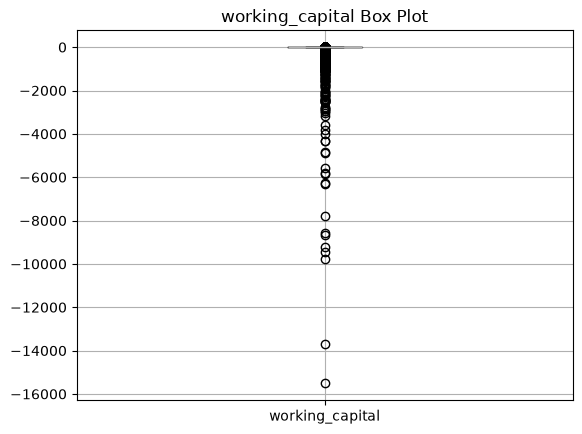

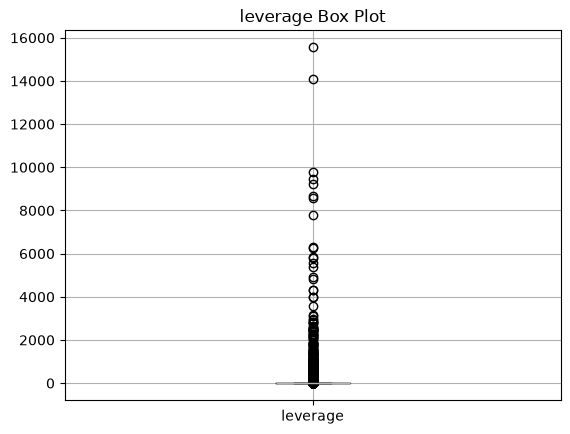

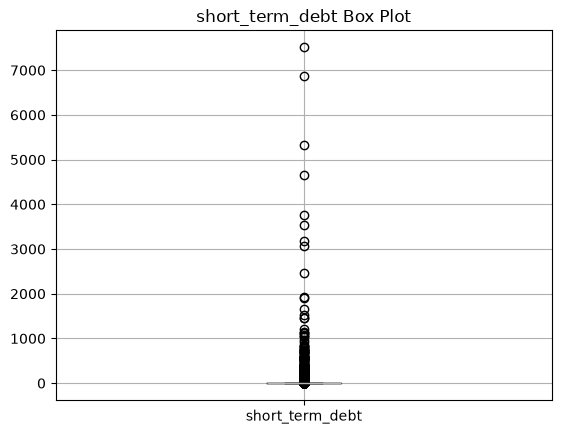

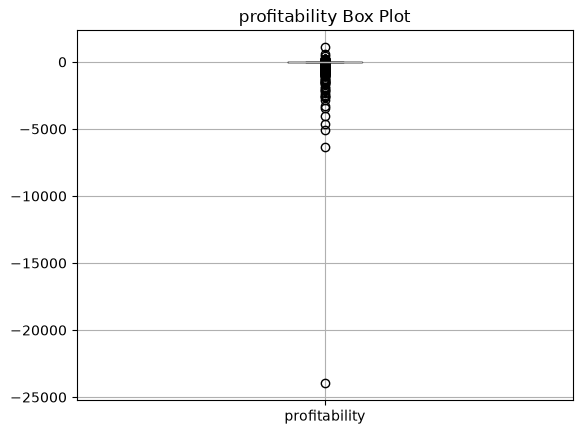

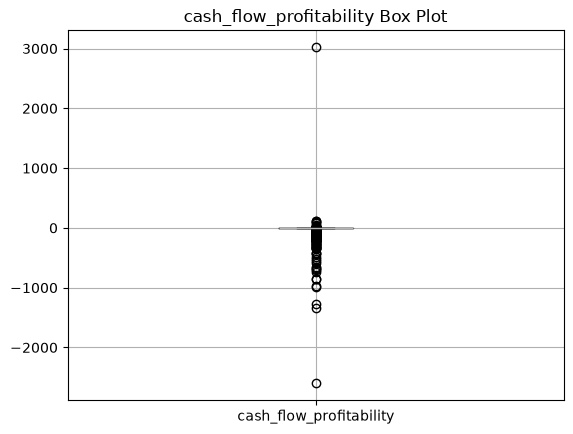

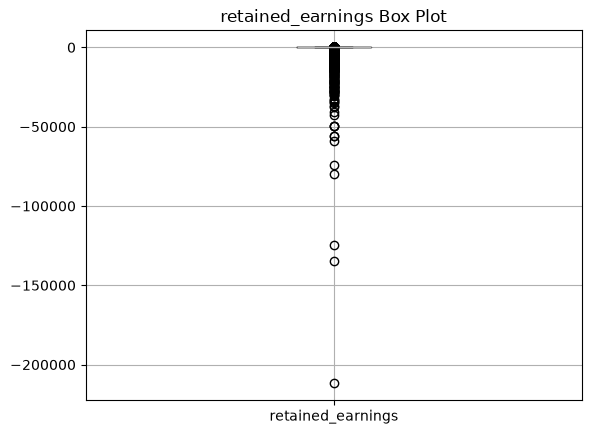

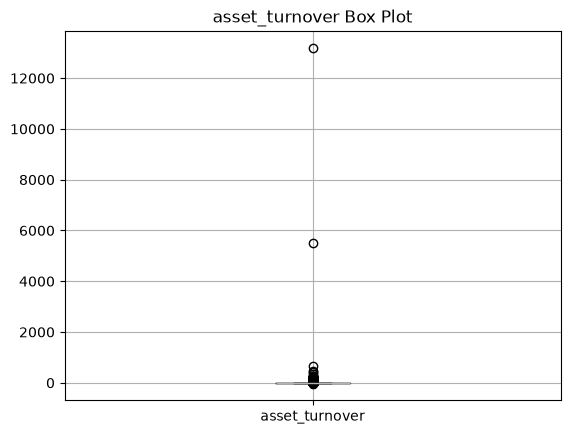

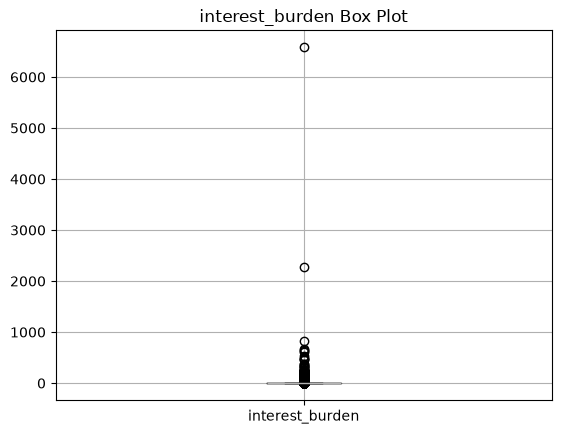

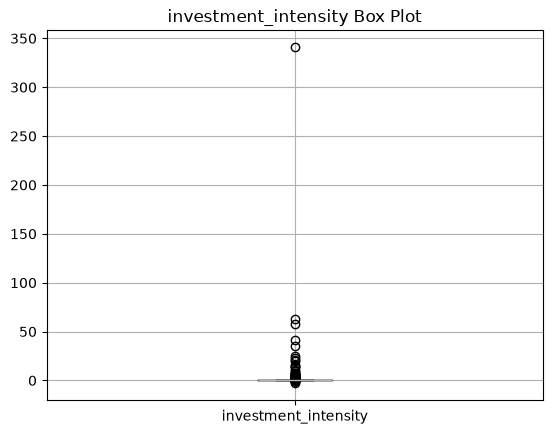

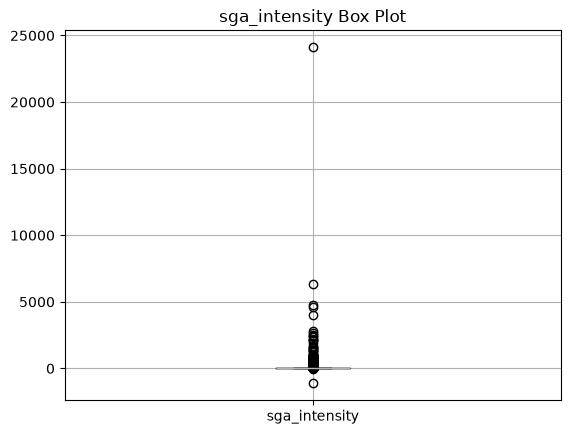

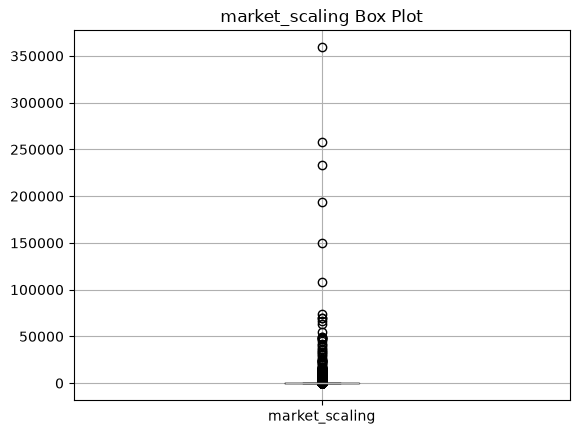

working_capital max/p99: 1.1302086508666158 min/p1: 822.3269647094265 822.3269647094265
leverage max/p99: 605.39445495209 min/p1: 0.0 0.0
short_term_debt max/p99: 1431.34626637008 min/p1: -inf -inf
profitability max/p99: 480.0975628612039 min/p1: 2504.9250354749515 2504.9250354749515
cash_flow_profitability max/p99: 7674.409215140764 min/p1: 567.0312417039979 567.0312417039979
retained_earnings max/p99: 172.22302330967773 min/p1: 980.4778916229179 980.4778916229179
asset_turnover max/p99: 2844.50161355118 min/p1: -inf -inf
interest_burden max/p99: 788.4875005588488 min/p1: -inf -inf
investment_intensity max/p99: 913.8683715653171 min/p1: -inf -inf
sga_intensity max/p99: 3341.280575239536 min/p1: -464.0745106688287 -464.0745106688287
market_scaling max/p99: 3584.1651792015414 min/p1: 7.814518093825112e-05 7.814518093825112e-05


C:\Users\admin\AppData\Local\Temp\ipykernel_24120\293644166.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  print(feature, "max/p99:" , max_val/p99 , "min/p1:" , min_val/p1, min_val/p1)
C:\Users\admin\AppData\Local\Temp\ipykernel_24120\293644166.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  print(feature, "max/p99:" , max_val/p99 , "min/p1:" , min_val/p1, min_val/p1)
C:\Users\admin\AppData\Local\Temp\ipykernel_24120\293644166.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  print(feature, "max/p99:" , max_val/p99 , "min/p1:" , min_val/p1, min_val/p1)
C:\Users\admin\AppData\Local\Temp\ipykernel_24120\293644166.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  print(feature, "max/p99:" , max_val/p99 , "min/p1:" , min_val/p1, min_val/p1)


'\nThe majority of accounting variables exhibited substantial outliers, with the maximum values exceeding the 99th percentile by more than a factor of 10 for almost all features. \nThis indicates the presence of a small number of extreme observations that may disproportionately influence model performance and therefore warrant treatment.\n'

In [11]:
outlier_description = final[features].describe()
#print(outlier_description) #investigating outliers to be able to do the next steps 

#Boxlplots for better visualisation
for feature in accounting_features:
    final.boxplot(column=feature)
    plt.title(feature + " Box Plot")
    plt.show()

for feature in accounting_features:
    p99 = train[feature].quantile(0.99)
    count = (train[feature] > p99).sum()
    max_val = train[feature].max()
    p1 = train[feature].quantile(0.01)
    min_val = train[feature].min()
    print(feature, "max/p99:" , max_val/p99 , "min/p1:" , min_val/p1, min_val/p1)

"""
The majority of accounting variables exhibited substantial outliers, with the maximum values exceeding the 99th percentile by more than a factor of 10 for almost all features. 
This indicates the presence of a small number of extreme observations that may disproportionately influence model performance and therefore warrant treatment.
"""


In [12]:
#Now we windorize the extreme values for each feature by calculating the 1rst and 99th percentile & replace the extreme values with those calculations
#new dataframe just in case we need to go back
for feature in accounting_features:
 p1 = train[feature].quantile(0.01)
 p99 = train[feature].quantile(0.99)
 train[feature] = train[feature].clip(lower=p1, upper=p99)
 val[feature]   = val[feature].clip(lower=p1, upper=p99)
 test[feature]  = test[feature].clip(lower=p1, upper=p99)


#rebuildind the x and y splits after imputation & winsorization
x_train, y_train = train[x], train["distress"]
x_val,   y_val   = val[x],   val["distress"]
x_test,  y_test  = test[x],  test["distress"]

#Save final unscaled dataframes to csv for RandomForest & XGBoost models
train.to_csv("data/processed/unscaled_train_final.csv", index=False)
val.to_csv("data/processed/unscaled_val_final.csv", index=False)
test.to_csv("data/processed/unscaled_test_final.csv", index=False)

# fit scaler on TRAIN only 
scaler = StandardScaler()
scaler.fit(x_train[accounting_features])

# keep all columns, including missing indicators
X_train_scaled = x_train.copy()
X_val_scaled   = x_val.copy()
X_test_scaled  = x_test.copy()

# scale only accounting_features; keep indicator cols unchanged
X_train_scaled[accounting_features] = scaler.transform(x_train[accounting_features])
X_val_scaled[accounting_features]   = scaler.transform(x_val[accounting_features])
X_test_scaled[accounting_features]  = scaler.transform(x_test[accounting_features])

X_train_scaled.to_csv("data/processed/scaled_train_final.csv", index=False)
X_val_scaled.to_csv("data/processed/scaled_val_final.csv", index=False)
X_test_scaled.to_csv("data/processed/scaled_test_final.csv", index=False)

In [13]:
# Checking for data leakage (run on split dataframes, not feature matrices)
assert train["year"].max() < val["year"].min()
assert val["year"].max() < test["year"].min()

train_keys = set(zip(train["gvkey"], train["datadate"]))
val_keys   = set(zip(val["gvkey"], val["datadate"]))
test_keys  = set(zip(test["gvkey"], test["datadate"]))

assert train_keys.isdisjoint(val_keys)
assert train_keys.isdisjoint(test_keys)
assert val_keys.isdisjoint(test_keys)

In [14]:

#check mean and std of scaled data, check for missing values and inf values
#display(X_train_scaled.describe().T[['mean', 'std']])

#display(X_train_scaled.isnull().sum().sort_values(ascending=False).head(20))

#display(np.isinf(X_train_scaled).sum().sort_values(ascending=False).head(20))
#X_train_scaled.shape #multicollinearity check

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42) #Class imbalance handled here
lr.fit(X_train_scaled, y_train) #train model on scaled training data
y_lr_pred = lr.predict(X_val_scaled)  #predict the target using the val dataset  (gives 0s and 1s) 
y_lr_prob = lr.predict_proba(X_val_scaled)[:, 1] #predict the probability of the positibe class



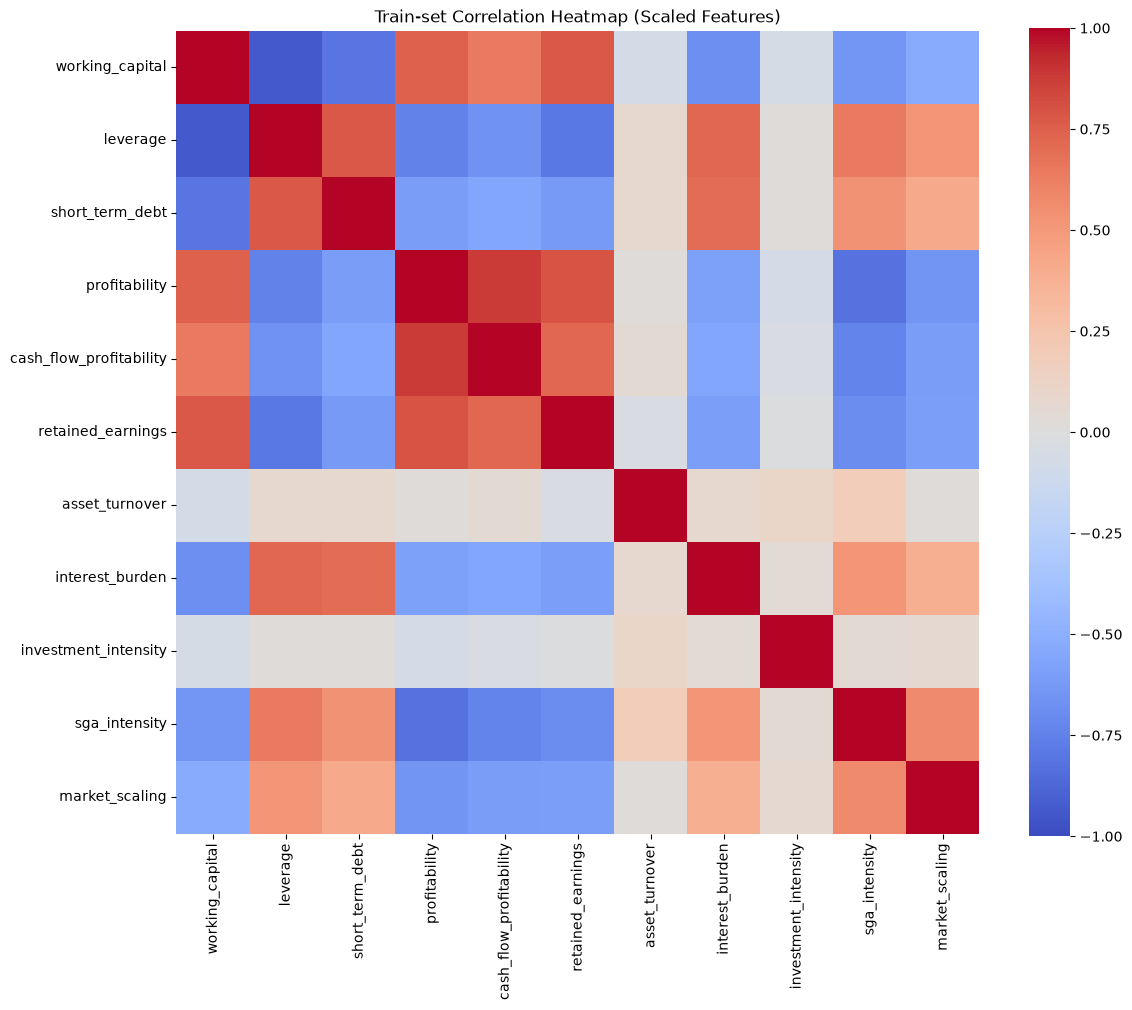

,var1,var2,abs_corr
1,working_capital,leverage,0.937443
37,profitability,cash_flow_profitability,0.877494
42,profitability,sga_intensity,0.827772
2,working_capital,short_term_debt,0.812004
16,leverage,retained_earnings,0.792283
38,profitability,retained_earnings,0.791309
13,leverage,short_term_debt,0.780087
5,working_capital,retained_earnings,0.778121
14,leverage,profitability,0.743516
3,working_capital,profitability,0.742836


,feature,VIF
1,working_capital,10.413076
2,leverage,9.948945
4,profitability,8.312748
5,cash_flow_profitability,4.607469
6,retained_earnings,3.759442
10,sga_intensity,3.688597
3,short_term_debt,3.349502
8,interest_burden,2.389039
11,market_scaling,1.820677
7,asset_turnover,1.186789


,feature,VIF
1,working_capital,10.413076
2,leverage,9.948945
4,profitability,8.312748


,feature,VIF
1,working_capital,10.413076


In [15]:

X_train_df = x_train[accounting_features].copy()
# Correlation heatmap
corr = X_train_scaled[accounting_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True
)
plt.title("Train-set Correlation Heatmap (Scaled Features)")
plt.tight_layout()
plt.show()

# strongest absolute pairwise correlations
upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)
display(top_pairs.head(20))


# VIF table
X_vif = x_train[accounting_features].copy()
# Add intercept column
X_vif_const = add_constant(X_vif, has_constant="add")
vif_all = pd.DataFrame({
    "feature": X_vif_const.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i)
            for i in range(X_vif_const.shape[1])]
}).sort_values("VIF", ascending=False)

# Drop intercept row for reporting
vif_df = vif_all[vif_all["feature"] != "const"].sort_values("VIF", ascending=False)
display(vif_df)

# Quick flags
display(vif_df[vif_df["VIF"] > 5])   # moderate concern
display(vif_df[vif_df["VIF"] > 10])  # serious concern

In [16]:
print("Total positives in final:", final["distress"].sum())
print("Train positives:", train["distress"].sum())
print("Val positives:", val["distress"].sum())
print("Val negatives:", val["distress"].size - val["distress"].sum())

Total positives in final: 230
Train positives: 108
Val positives: 51
Val negatives: 23528


In [17]:
#Validation
accuracy = accuracy_score(y_val, y_lr_pred)
precision = precision_score(y_val, y_lr_pred)
recall = recall_score(y_val, y_lr_pred)
f1 = f1_score(y_val, y_lr_pred)
roc_auc = roc_auc_score(y_val, y_lr_prob)
pr_auc = average_precision_score(y_val, y_lr_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("PR AUC:", pr_auc)  

print("**********************")
print("Confusion Matrix:")
cm = confusion_matrix(y_val, y_lr_pred)
print(cm)

best = None
feasible_list = []

for threshold in np.arange(0.05, 0.96, 0.01):
    y_hat = (y_lr_prob >= threshold).astype(int)
    p = precision_score(y_val, y_hat, zero_division=0)
    r = recall_score(y_val, y_hat, zero_division=0)

    feasible = (r >= 0.60) and (p >= 0.01)
    if feasible:
        feasible_list.append([threshold, r, p])

print(len(feasible_list))
'''
Also tried this , which gave high recall but lower precision
for threshold in np.arange(0.05, 0.96, 0.01):
    y_hat = (y_lr_prob >= threshold).astype(int)
    p = precision_score(y_val, y_hat, zero_division=0)
    r = recall_score(y_val, y_hat, zero_division=0)
    # F2 = (1+2^2)PR / (2^2 P + R) = 5PR / (4P + R)
    f2 = (5 * p * r) / (4 * p + r) if (4 * p + r) > 0 else 0.0
    feasible = (f2 >= 0.02)   # set your F2 floor here
    if feasible:
        feasible_list.append([threshold, r, p, f2])
'''
if feasible_list:
    best = max(feasible_list, key=lambda x: (x[1], x[2]))  # max recall, then precision
    print("Best feasible threshold:", best[0])
    print("Best recall:", best[1])
    print("Best precision:", best[2])

if best is None:
    print("No feasible threshold found for current constraints.")
else:
    best_threshold = best[0]
    y_val_pred_best = (y_lr_prob >= best_threshold).astype(int)
    cm3 = confusion_matrix(y_val, y_val_pred_best)
    print(cm3)



Accuracy: 0.8058017727639001
Precision: 0.008893709327548807
Recall: 0.803921568627451
F1-score: 0.017592791246513622
ROC-AUC: 0.8171202772166329
PR AUC: 0.018622849702197266
**********************
Confusion Matrix:
[[18959  4569]
 [   10    41]]
2
Best feasible threshold: 0.5300000000000001
Best recall: 0.6862745098039216
Best precision: 0.010127314814814815
[[20107  3421]
 [   16    35]]


In [18]:
#RF and XGboost
rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=5,
    class_weight="balanced_subsample",   # handles imbalance
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)
rf_val_pred = rf.predict(x_val)
rf_val_prob = rf.predict_proba(x_val)[:, 1]

pos = y_train.sum()
neg = len(y_train) - pos
spw = neg / pos   # scale_pos_weight

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=spw,   # handles imbalance
    n_jobs=-1,
    random_state=42
)

xgb.fit(x_train, y_train)
xgb_train_pred = xgb.predict(x_train)
xgb_train_prob = xgb.predict_proba(x_train)[:, 1]
xgb_val_pred = xgb.predict(x_val)
xgb_val_prob = xgb.predict_proba(x_val)[:, 1]


print(rf_val_pred.sum())
print(rf_val_prob.max())
#Since this shows only 3 positive cases , we run the same threshold algorithm on this model in order to find the best threshold here too.

3
0.6483050047136986


In [19]:
#Hypertuning all three models here. These are some trials to try and figure out if the models generalise well or whether there could be overfitting/ underfitting. T



#We need to compare the evaluation metrics of the train vs validation of the 3 models.

#Logitic Regression
'''
list of models
list of metrics
Model | metric | Train |Validation
LR 
'''
LR_precision_train = precision_score(y_train, lr.predict(X_train_scaled), zero_division=0)
LR_recall_train = recall_score(y_train, lr.predict(X_train_scaled), zero_division=0)
LR_ROC_AUC_train = roc_auc_score(y_train, lr.predict_proba(X_train_scaled)[:,1])
LR_PR_AUC_train = average_precision_score(y_train, lr.predict_proba(X_train_scaled)[:,1])
#LOG LOSS?
LR_precision_val = precision_score(y_val, y_lr_pred, zero_division=0)
LR_recall_val = recall_score(y_val, y_lr_pred, zero_division=0)
LR_ROC_AUC_val = roc_auc_score(y_val, y_lr_prob)
LR_PR_AUC_val = average_precision_score(y_val, y_lr_prob)
LR_logloss_train = log_loss(y_train, lr.predict_proba(X_train_scaled)[:, 1])
LR_logloss_val   = log_loss(y_val, y_lr_prob)
rows = {
    "Precision"  : ["LR",LR_precision_train,LR_precision_val],
    "Recall" : ["LR",LR_recall_train,LR_recall_val],
    "ROC_AUC" : ["LR",LR_ROC_AUC_train,LR_ROC_AUC_val],
    "PR_AUC" : ["LR",LR_PR_AUC_train,LR_PR_AUC_val],
    "Log Loss" : ["LR",LR_logloss_train,LR_logloss_val]
}

table = pd.DataFrame(rows, index = ["Model","Train", "Validation"]).T
display(table)

,Model,Train,Validation
Precision,LR,0.003819,0.008894
Recall,LR,0.740741,0.803922
ROC_AUC,LR,0.812472,0.81712
PR_AUC,LR,0.008469,0.018623
Log Loss,LR,0.57512,0.568292


In [20]:
#Tuning C and Refitting + finding another best threshold for this model.
best_C = None
best_pr_auc = 0

for C in [0.01,0.1,1,3,10]:
    lr  = LogisticRegression(
        C=C,
        penalty ="l2",
        solver = "lbfgs",
        class_weight = "balanced",
        max_iter=2000,
        random_state = 42
    )
    lr.fit(X_train_scaled, y_train)
    y_prob = lr.predict_proba(X_val_scaled)[:,1]
    pr_auc = average_precision_score(y_val, y_prob)

    print(f"C:{C} | val PR-AUC :{pr_auc:.6f}")
    if pr_auc > best_pr_auc:
     best_pr_auc = pr_auc
     best_C = C


print("Best C:", best_C, "Best val PR-AUC:", best_pr_auc)
#Refit
lr_best = LogisticRegression(
    C=best_C,
    penalty="l2",
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)
lr_best.fit(X_train_scaled, y_train)


#Rerun to look for any difference after tuning
y_lr_pred = lr_best.predict(X_val_scaled)  
y_lr_prob = lr_best.predict_proba(X_val_scaled)[:, 1]
LR_precision_train = precision_score(y_train, lr_best.predict(X_train_scaled), zero_division=0)
LR_recall_train = recall_score(y_train, lr_best.predict(X_train_scaled), zero_division=0)
LR_ROC_AUC_train = roc_auc_score(y_train, lr_best.predict_proba(X_train_scaled)[:,1])
LR_PR_AUC_train = average_precision_score(y_train, lr_best.predict_proba(X_train_scaled)[:,1])
#LOG LOSS?
LR_precision_val = precision_score(y_val, y_lr_pred, zero_division=0)
LR_recall_val = recall_score(y_val, y_lr_pred, zero_division=0)
LR_ROC_AUC_val = roc_auc_score(y_val, y_lr_prob)
LR_PR_AUC_val = average_precision_score(y_val, y_lr_prob)
LR_logloss_train = log_loss(y_train, lr_best.predict_proba(X_train_scaled)[:, 1])
LR_logloss_val   = log_loss(y_val, y_lr_prob)
rows = {
    "Precision"  : ["LR",LR_precision_train,LR_precision_val],
    "Recall" : ["LR",LR_recall_train,LR_recall_val],
    "ROC_AUC" : ["LR",LR_ROC_AUC_train,LR_ROC_AUC_val],
    "PR_AUC" : ["LR",LR_PR_AUC_train,LR_PR_AUC_val],
    "Log Loss" : ["LR",LR_logloss_train,LR_logloss_val]
}

table = pd.DataFrame(rows, index = ["Model","Train", "Validation"]).T
display(table)


c:\Users\admin\Work\dissertation\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


C:0.01 | val PR-AUC :0.019122


c:\Users\admin\Work\dissertation\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


C:0.1 | val PR-AUC :0.018677


c:\Users\admin\Work\dissertation\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


...

C:3 | val PR-AUC :0.018609


c:\Users\admin\Work\dissertation\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


C:10 | val PR-AUC :0.018619
Best C: 0.01 Best val PR-AUC: 0.019121540148751375


c:\Users\admin\Work\dissertation\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Model,Train,Validation
Precision,LR,0.003908,0.009059
Recall,LR,0.731481,0.803922
ROC_AUC,LR,0.813378,0.821406
PR_AUC,LR,0.009738,0.019122
Log Loss,LR,0.575978,0.569539


In [21]:
#Random Forest Validation , same framework we just check our evalutaion metrics for  validation and train values.

#Random Forect
'''
Model | metric | Train |Validation
RF
'''

RF_precision_train = precision_score(y_train, rf.predict(x_train), zero_division=0)
RF_recall_train = recall_score(y_train, rf.predict(x_train), zero_division=0)
RF_ROC_AUC_train = roc_auc_score(y_train, rf.predict_proba(x_train)[:,1])
RF_PR_AUC_train = average_precision_score(y_train, rf.predict_proba(x_train)[:,1])
RF_logloss_train = log_loss(y_train, rf.predict_proba(x_train)[:, 1])

RF_precision_val = precision_score(y_val, rf_val_pred, zero_division=0)
RF_recall_val = recall_score(y_val, rf_val_pred, zero_division=0)
RF_ROC_AUC_val = roc_auc_score(y_val, rf_val_prob)
RF_PR_AUC_val = average_precision_score(y_val, rf_val_prob)
RF_logloss_val   = log_loss(y_val, rf_val_prob)
rows = {
    "Precision"  : ["RF",RF_precision_train,RF_precision_val],
    "Recall" : ["RF",RF_recall_train,RF_recall_val],
    "ROC_AUC" : ["RF",RF_ROC_AUC_train,RF_ROC_AUC_val],
    "PR_AUC" : ["RF",RF_PR_AUC_train,RF_PR_AUC_val],
    "Log Loss" : ["RF",RF_logloss_train,RF_logloss_val]
}

table = pd.DataFrame(rows, index = ["Model","Train", "Validation"]).T
display(table)

,Model,Train,Validation
Precision,RF,0.955752,0.0
Recall,RF,1.0,0.0
ROC_AUC,RF,0.999973,0.903498
PR_AUC,RF,0.967706,0.028186
Log Loss,RF,0.006017,0.01669


In [22]:
print("Distress" , y_test.sum() , "All" , len(y_test))
print("Distress" , y_val.sum() , "All" , len(y_val))


Distress 71 All 36666
Distress 51 All 23579


In [23]:
'''
#I created a grid search to get the best hyperparamaters that would give us the best PR-AUC  score.
param_grid ={
    "n_estimators" : [300,600],
    "max_depth" : [4,6,8],
    "min_samples_leaf" : [1, 5, 10, 20],
    "min_samples_split" :[2, 10, 20, 50],
    "class_weight":["balanced_subsample"],
    "max_features": ["sqrt", 0.5]
}

best_rf_params = None
best_pr_auc = 0
best_roc_auc = 0


for param in ParameterGrid(param_grid):
    rf = RandomForestClassifier(**param, random_state=42,n_jobs=-1)
    rf.fit(x_train, y_train)
    val_prob = rf.predict_proba(x_val)[:,1]


    pr_auc = average_precision_score(y_val, val_prob)
    roc_auc = roc_auc_score(y_val,val_prob)

    if best_rf_params is None or pr_auc > best_pr_auc:
        best_rf_params = param
        best_pr_auc = pr_auc
        best_roc_auc = roc_auc


print("Best Hyperparameters:", best_rf_params)
print("Best PR AUC :", best_pr_auc)
print("ROC_AUC at best:", best_roc_auc)
'''


'\n#I created a grid search to get the best hyperparamaters that would give us the best PR-AUC  score.\nparam_grid ={\n    "n_estimators" : [300,600],\n    "max_depth" : [4,6,8],\n    "min_samples_leaf" : [1, 5, 10, 20],\n    "min_samples_split" :[2, 10, 20, 50],\n    "class_weight":["balanced_subsample"],\n    "max_features": ["sqrt", 0.5]\n}\n\nbest_rf_params = None\nbest_pr_auc = 0\nbest_roc_auc = 0\n\n\nfor param in ParameterGrid(param_grid):\n    rf = RandomForestClassifier(**param, random_state=42,n_jobs=-1)\n    rf.fit(x_train, y_train)\n    val_prob = rf.predict_proba(x_val)[:,1]\n\n\n    pr_auc = average_precision_score(y_val, val_prob)\n    roc_auc = roc_auc_score(y_val,val_prob)\n\n    if best_rf_params is None or pr_auc > best_pr_auc:\n        best_rf_params = param\n        best_pr_auc = pr_auc\n        best_roc_auc = roc_auc\n\n\nprint("Best Hyperparameters:", best_rf_params)\nprint("Best PR AUC :", best_pr_auc)\nprint("ROC_AUC at best:", best_roc_auc)\n'

In [24]:
'''
#Now with these values, we refit ,and check the same evaluation metrics for train and validation to see if we have improved the model performance.

rf_best = RandomForestClassifier(**best_rf_params, random_state=42,n_jobs=-1)
rf_best.fit(x_train, y_train)


rf_train_pred = rf_best.predict(x_train)
rf_train_prob = rf_best.predict_proba(x_train)[:, 1]
rf_val_pred   = rf_best.predict(x_val)
rf_val_prob   = rf_best.predict_proba(x_val)[:, 1]

 
RF_precision_train = precision_score(y_train, rf_train_pred, zero_division=0)
RF_recall_train = recall_score(y_train, rf_train_pred, zero_division=0)
RF_ROC_AUC_train = roc_auc_score(y_train, rf_train_prob)
RF_PR_AUC_train = average_precision_score(y_train, rf_train_prob)
RF_logloss_train = log_loss(y_train, rf_train_prob)

RF_precision_val = precision_score(y_val, rf_val_pred, zero_division=0)
RF_recall_val = recall_score(y_val, rf_val_pred, zero_division=0)
RF_ROC_AUC_val = roc_auc_score(y_val, rf_val_prob)
RF_PR_AUC_val = average_precision_score(y_val, rf_val_prob)
RF_logloss_val   = log_loss(y_val, rf_val_prob)
rows = {
    "Precision"  : ["RF",RF_precision_train,RF_precision_val],
    "Recall" : ["RF",RF_recall_train,RF_recall_val],
    "ROC_AUC" : ["RF",RF_ROC_AUC_train,RF_ROC_AUC_val],
    "PR_AUC" : ["RF",RF_PR_AUC_train,RF_PR_AUC_val],
    "Log Loss" : ["RF",RF_logloss_train,RF_logloss_val]
}

table = pd.DataFrame(rows, index = ["Model","Train", "Validation"]).T
display(table)
'''


'\n#Now with these values, we refit ,and check the same evaluation metrics for train and validation to see if we have improved the model performance.\n\nrf_best = RandomForestClassifier(**best_rf_params, random_state=42,n_jobs=-1)\nrf_best.fit(x_train, y_train)\n\n\nrf_train_pred = rf_best.predict(x_train)\nrf_train_prob = rf_best.predict_proba(x_train)[:, 1]\nrf_val_pred   = rf_best.predict(x_val)\nrf_val_prob   = rf_best.predict_proba(x_val)[:, 1]\n\n\nRF_precision_train = precision_score(y_train, rf_train_pred, zero_division=0)\nRF_recall_train = recall_score(y_train, rf_train_pred, zero_division=0)\nRF_ROC_AUC_train = roc_auc_score(y_train, rf_train_prob)\nRF_PR_AUC_train = average_precision_score(y_train, rf_train_prob)\nRF_logloss_train = log_loss(y_train, rf_train_prob)\n\nRF_precision_val = precision_score(y_val, rf_val_pred, zero_division=0)\nRF_recall_val = recall_score(y_val, rf_val_pred, zero_division=0)\nRF_ROC_AUC_val = roc_auc_score(y_val, rf_val_prob)\nRF_PR_AUC_val = a

In [25]:
#XGBoost Validation , same framework we just check our evalutaion metrics for  validation and train values.
#XGBoost metrics

xgb_precision_train = precision_score(y_train, xgb_train_pred, zero_division=0)
xgb_recall_train    = recall_score(y_train, xgb_train_pred, zero_division=0)
xgb_ROC_AUC_train   = roc_auc_score(y_train, xgb_train_prob)
xgb_PR_AUC_train    = average_precision_score(y_train, xgb_train_prob)
xgb_logloss_train   = log_loss(y_train, xgb_train_prob)
xgb_precision_val = precision_score(y_val, xgb_val_pred, zero_division=0)
xgb_recall_val    = recall_score(y_val, xgb_val_pred, zero_division=0)
xgb_ROC_AUC_val   = roc_auc_score(y_val, xgb_val_prob)
xgb_PR_AUC_val    = average_precision_score(y_val, xgb_val_prob)
xgb_logloss_val   = log_loss(y_val, xgb_val_prob)


rows = {
    "Precision": ["XGB", xgb_precision_train, xgb_precision_val],
    "Recall":    ["XGB", xgb_recall_train, xgb_recall_val],
    "ROC_AUC":   ["XGB", xgb_ROC_AUC_train, xgb_ROC_AUC_val],
    "PR_AUC":    ["XGB", xgb_PR_AUC_train, xgb_PR_AUC_val],
    "Log Loss":  ["XGB", xgb_logloss_train, xgb_logloss_val],
}

table = pd.DataFrame(rows, index = ["Model","Train", "Validation"]).T
display(table)


#Results show overfitting, check thresohld, if  results are still weak , will tune. 
#Validation
accuracy = accuracy_score(y_val, xgb_val_pred)
precision = precision_score(y_val, xgb_val_pred,zero_division=0)
recall = recall_score(y_val, xgb_val_pred,zero_division=0)
f1 = f1_score(y_val, xgb_val_pred,zero_division=0)
roc_auc = roc_auc_score(y_val, xgb_val_prob)
pr_auc = average_precision_score(y_val, xgb_val_prob)

best = None
feasible_list = []

for threshold in np.arange(0.0, 1.001, 0.001):
    y_hat = (xgb_val_prob >= threshold).astype(int)
    p = precision_score(y_val, y_hat, zero_division=0)
    r = recall_score(y_val, y_hat, zero_division=0)

    feasible = (r >= 0.60) and (p >= 0.01)
    if feasible:
        feasible_list.append([threshold, r, p])

print(len(feasible_list))

if feasible_list:
    best = max(feasible_list, key=lambda x: (x[1], x[2]))  # max recall, then precision
    print("Best feasible threshold:", best[0])
    print("Best recall:", best[1])
    print("Best precision:", best[2])

if best is None:
    print("No feasible threshold found for current constraints.")
else:
    best_xgb_threshold = best[0]
    xgb_val_pred_best = (xgb_val_prob >= best_xgb_threshold).astype(int)
    cm5 = confusion_matrix(y_val, xgb_val_pred_best)
    print(cm5)

''' SUPPOSED TO BE 
xgb_precision_train = precision_score(y_train, xgb_train_pred, zero_division=0)
xgb_recall_train    = recall_score(y_train, xgb_train_pred, zero_division=0)
xgb_ROC_AUC_train   = roc_auc_score(y_train, xgb_train_prob)
xgb_PR_AUC_train    = average_precision_score(y_train, xgb_train_prob)
xgb_logloss_train   = log_loss(y_train, xgb_train_prob)
xgb_precision_val = precision_score(y_val, xgb_val_pred_best, zero_division=0)
xgb_recall_val    = recall_score(y_val, xgb_val_pred_best, zero_division=0)
xgb_ROC_AUC_val   = roc_auc_score(y_val, xgb_val_pred_best)
xgb_PR_AUC_val    = average_precision_score(y_val, xgb_val_pred_best)
xgb_logloss_val   = log_loss(y_val, xgb_val_pred_best)

rows = {
    "Precision": ["XGB", xgb_precision_train, xgb_precision_val],
    "Recall":    ["XGB", xgb_recall_train, xgb_recall_val],
    "ROC_AUC":   ["XGB", xgb_ROC_AUC_train, xgb_ROC_AUC_val],
    "PR_AUC":    ["XGB", xgb_PR_AUC_train, xgb_PR_AUC_val],
    "Log Loss":  ["XGB", xgb_logloss_train, xgb_logloss_val],
}

table = pd.DataFrame(rows, index = ["Model","Train", "Validation"]).T
display(table)
'''


,Model,Train,Validation
Precision,XGB,0.279793,0.012658
Recall,XGB,1.0,0.019608
ROC_AUC,XGB,0.999996,0.880542
PR_AUC,XGB,0.996616,0.018547
Log Loss,XGB,0.011129,0.019958


5
Best feasible threshold: 0.002
Best recall: 0.7843137254901961
Best precision: 0.01199400299850075
[[20233  3295]
 [   11    40]]


' SUPPOSED TO BE \nxgb_precision_train = precision_score(y_train, xgb_train_pred, zero_division=0)\nxgb_recall_train    = recall_score(y_train, xgb_train_pred, zero_division=0)\nxgb_ROC_AUC_train   = roc_auc_score(y_train, xgb_train_prob)\nxgb_PR_AUC_train    = average_precision_score(y_train, xgb_train_prob)\nxgb_logloss_train   = log_loss(y_train, xgb_train_prob)\nxgb_precision_val = precision_score(y_val, xgb_val_pred_best, zero_division=0)\nxgb_recall_val    = recall_score(y_val, xgb_val_pred_best, zero_division=0)\nxgb_ROC_AUC_val   = roc_auc_score(y_val, xgb_val_pred_best)\nxgb_PR_AUC_val    = average_precision_score(y_val, xgb_val_pred_best)\nxgb_logloss_val   = log_loss(y_val, xgb_val_pred_best)\n\nrows = {\n    "Precision": ["XGB", xgb_precision_train, xgb_precision_val],\n    "Recall":    ["XGB", xgb_recall_train, xgb_recall_val],\n    "ROC_AUC":   ["XGB", xgb_ROC_AUC_train, xgb_ROC_AUC_val],\n    "PR_AUC":    ["XGB", xgb_PR_AUC_train, xgb_PR_AUC_val],\n    "Log Loss":  ["XGB

IndentationError: expected an indented block after 'for' statement on line 36 (1601995749.py, line 37)

In [ ]:

#checked tuned first and now the threshold needs to be adjusted so ill find the best threshold for the tuned models and then setting the best threshold.
#Best threshold alogirithm
best_rf_threshold_row = None
feasible_list = []

#1. Threshold RF 

for threshold in np.arange(0.0, 1.001, 0.001):
    y_hat = (rf_val_prob >= threshold).astype(int)
    p = precision_score(y_val, y_hat, zero_division=0)
    r = recall_score(y_val, y_hat, zero_division=0)

    feasible = (r >= 0.60) and (p >= 0.01)
    if feasible:
        feasible_list.append([threshold, r, p])


if feasible_list:
    best_rf_threshold_row = max(feasible_list, key=lambda x: (x[1], x[2]))  # max recall, then precision
    print("Best feasible threshold RF:", best_rf_threshold_row[0])
    print("Best recall RF:", best_rf_threshold_row[1])
    print("Best precision RF:", best_rf_threshold_row[2])

if best_rf_threshold_row is None:
    print("RF: No feasible threshold found for current constraints.")
else:
    # 2.Setting the best threshold for the RF model.
    best_rf_threshold = best_rf_threshold_row[0]
    rf_val_pred_tuned = (rf_val_prob >= best_rf_threshold).astype(int)
    cm4 = confusion_matrix(y_val, rf_val_pred_tuned)
    print(cm4)

#1. Threshold LR 

best_lr_threshold_row = None
feasible_list = []

for threshold in np.arange(0.0, 1.001, 0.001):
    y_hat = (y_lr_prob >= threshold).astype(int)
    p = precision_score(y_val, y_hat, zero_division=0)
    r = recall_score(y_val, y_hat, zero_division=0)

    feasible = (r >= 0.60) and (p >= 0.01)
    if feasible:
        feasible_list.append([threshold, r, p])


if feasible_list:
    best_lr_threshold_row = max(feasible_list, key=lambda x: (x[1], x[2]))  # max recall, then precision
    print("Best feasible threshold LR:", best_lr_threshold_row[0])
    print("Best recall LR:", best_lr_threshold_row[1])
    print("Best precision LR:", best_lr_threshold_row[2])

if best_lr_threshold_row is None:
    print("LR: No feasible threshold found for current constraints.")
else:
    #Setting the best threshold for the LR model.
    best_lr_threshold = best_lr_threshold_row[0]
    lr_val_pred_tuned = (y_lr_prob >= best_lr_threshold).astype(int)
    cm4 = confusion_matrix(y_val, lr_val_pred_tuned)
    print(cm4)

Best feasible threshold RF: 0.322
Best recall RF: 0.9019607843137255
Best precision RF: 0.01041195110909914
[[19156  4372]
 [    5    46]]
Best feasible threshold LR: 0.518
Best recall LR: 0.7647058823529411
Best precision LR: 0.01050646551724138
[[19855  3673]
 [   12    39]]


In [28]:
# TUNING XGBOOST

# 1) Search space (regularized on purpose to reduce overfitting)
param_grid_xgb = {
    "max_depth": [2, 3, 4],
    "min_child_weight": [5, 10],
    "gamma": [0, 1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "reg_lambda": [1, 5],
    "reg_alpha": [0, 0.5],
    "learning_rate": [0.03, 0.05],
    "scale_pos_weight": [spw, spw * 1.25],
}

# 2) Optional: sample candidates for speed (set max_candidates=None to run full grid)
all_candidates = list(ParameterGrid(param_grid_xgb))
max_candidates = 80  # keep runtime manageable
rng = np.random.RandomState(42)

if (max_candidates is not None) and (len(all_candidates) > max_candidates):
    pick_idx = rng.choice(len(all_candidates), size=max_candidates, replace=False)
    candidates = [all_candidates[i] for i in pick_idx]
else:
    candidates = all_candidates

print(f"Trying {len(candidates)} / {len(all_candidates)} parameter combinations...")

# 3) Tune by validation PR-AUC (tie-breaker: ROC-AUC)
results = []
best_xgb_params = None
best_xgb_pr_auc = -np.inf
best_xgb_roc_auc = -np.inf

for i, p in enumerate(candidates, start=1):
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=2000,
        early_stopping_rounds=50,  # for your xgboost version: put in constructor
        n_jobs=-1,
        random_state=42,
        tree_method="hist",
        **p
    )

    model.fit(
        x_train,
        y_train,
        eval_set=[(x_val, y_val)],
        verbose=False
    )

    val_prob = model.predict_proba(x_val)[:, 1]
    pr_auc = average_precision_score(y_val, val_prob)
    roc_auc = roc_auc_score(y_val, val_prob)
    ll = log_loss(y_val, val_prob)

    results.append({
        "trial": i,
        "pr_auc_val": pr_auc,
        "roc_auc_val": roc_auc,
        "logloss_val": ll,
        "best_iteration": getattr(model, "best_iteration", None),
        **p
    })

    if (pr_auc > best_xgb_pr_auc) or (
        np.isclose(pr_auc, best_xgb_pr_auc) and roc_auc > best_xgb_roc_auc
    ):
        best_xgb_pr_auc = pr_auc
        best_xgb_roc_auc = roc_auc
        best_xgb_params = p

# 4) Showing top trials
results_df = pd.DataFrame(results).sort_values(
    ["pr_auc_val", "roc_auc_val"], ascending=False
).reset_index(drop=True)

display(results_df.head(10))

print("Best XGB params:", best_xgb_params)
print("Best validation PR-AUC:", best_xgb_pr_auc)
print("Best validation ROC-AUC:", best_xgb_roc_auc)

# 5) Refit best model
xgb_best = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=2000,
    early_stopping_rounds=50,
    n_jobs=-1,
    random_state=42,
    tree_method="hist",
    **best_xgb_params
)

xgb_best.fit(
    x_train,
    y_train,
    eval_set=[(x_val, y_val)],
    verbose=False
)

# 6) Predictions from tuned model
xgb_best_train_prob = xgb_best.predict_proba(x_train)[:, 1]
xgb_best_val_prob = xgb_best.predict_proba(x_val)[:, 1]

# Default threshold = 0.5 (before threshold tuning)
xgb_best_train_pred_05 = (xgb_best_train_prob >= 0.5).astype(int)
xgb_best_val_pred_05 = (xgb_best_val_prob >= 0.5).astype(int)

# 7) Metrics
xgb_precision_train = precision_score(y_train, xgb_best_train_pred_05, zero_division=0)
xgb_recall_train = recall_score(y_train, xgb_best_train_pred_05, zero_division=0)
xgb_ROC_AUC_train = roc_auc_score(y_train, xgb_best_train_prob)
xgb_PR_AUC_train = average_precision_score(y_train, xgb_best_train_prob)
xgb_logloss_train = log_loss(y_train, xgb_best_train_prob)

xgb_precision_val = precision_score(y_val, xgb_best_val_pred_05, zero_division=0)
xgb_recall_val = recall_score(y_val, xgb_best_val_pred_05, zero_division=0)
xgb_ROC_AUC_val = roc_auc_score(y_val, xgb_best_val_prob)
xgb_PR_AUC_val = average_precision_score(y_val, xgb_best_val_prob)
xgb_logloss_val = log_loss(y_val, xgb_best_val_prob)

rows = {
    "Precision": ["XGB_tuned", xgb_precision_train, xgb_precision_val],
    "Recall": ["XGB_tuned", xgb_recall_train, xgb_recall_val],
    "ROC_AUC": ["XGB_tuned", xgb_ROC_AUC_train, xgb_ROC_AUC_val],
    "PR_AUC": ["XGB_tuned", xgb_PR_AUC_train, xgb_PR_AUC_val],
    "Log Loss": ["XGB_tuned", xgb_logloss_train, xgb_logloss_val],
}
table = pd.DataFrame(rows, index=["Model", "Train", "Validation"]).T
display(table)

Trying 80 / 768 parameter combinations...


,trial,pr_auc_val,roc_auc_val,logloss_val,best_iteration,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,reg_alpha,reg_lambda,scale_pos_weight,subsample
0,77,0.082519,0.920022,0.275913,46,0.9,1,0.05,3,10,0.5,5,1129.340278,0.7
1,49,0.081337,0.919757,0.281482,107,0.7,1,0.05,2,5,0.5,1,1129.340278,0.9
2,2,0.077834,0.927294,0.216519,62,0.7,1,0.05,3,5,0.0,5,903.472222,0.7
3,10,0.077834,0.927294,0.216519,62,0.7,0,0.05,3,10,0.0,5,903.472222,0.7
4,7,0.077558,0.920229,0.262186,94,0.7,0,0.05,2,5,0.0,1,903.472222,0.9
5,74,0.077549,0.920237,0.262404,94,0.7,0,0.05,2,5,0.5,5,903.472222,0.9
6,16,0.074123,0.924430,0.194812,47,0.7,1,0.05,4,5,0.0,5,903.472222,0.7
7,57,0.073538,0.916661,0.201912,49,0.7,1,0.05,4,5,0.5,1,903.472222,0.9
8,46,0.073317,0.917955,0.360314,93,0.7,0,0.03,2,10,0.5,5,1129.340278,0.9
9,13,0.073317,0.917954,0.360298,93,0.7,1,0.03,2,5,0.0,5,1129.340278,0.9


Best XGB params: {'colsample_bytree': 0.9, 'gamma': 1, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'reg_alpha': 0.5, 'reg_lambda': 5, 'scale_pos_weight': np.float64(1129.3402777777778), 'subsample': 0.7}
Best validation PR-AUC: 0.08251901919151626
Best validation ROC-AUC: 0.9200218679787453


,Model,Train,Validation
Precision,XGB_tuned,0.00854,0.017399
Recall,XGB_tuned,0.953704,0.784314
ROC_AUC,XGB_tuned,0.964412,0.920022
PR_AUC,XGB_tuned,0.022675,0.082519
Log Loss,XGB_tuned,0.311255,0.275913
